# Trabajo Practico Final
Integrantes:
* Agustin Fernandez Berge
* Ramiro Gatto 

Primero importamos todas las libreraias que vamos a ir usando durante el proyecto

In [1]:
import os
import time
import keras
import numpy as np
import matplotlib.pyplot as plt

from datetime import timedelta
from keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2025-07-27 19:41:02.823990: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-27 19:41:02.837766: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-27 19:41:02.923816: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-27 19:41:03.005704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753656063.097416   13914 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753656063.12

Definimos funciones para mostrar las gráficas utilizadas durante el proyecto

In [18]:
def curvasEntrenamiento(history, history_fine_tune=None, test_values=None):
    plt.figure(figsize=(12, 5))
    train_color = '#1f77b4'
    validation_color = '#ff7f0e'
    train_finetunning_color = '#0d3d6b'
    validation_finetunning_color = '#b36b00'
    test_color = '#e74c3c'
    test_after_finetunning_color = '#27ae60'

    extra_ticks = []

    # Accuracy
    plt.subplot(1, 2, 1)
    # Grafico las curvas de entrenamiento y validación iniciales
    plt.plot(history.history['accuracy'], label='Entrenamiento (Inicial)', color=train_color, linestyle='-')
    plt.plot(history.history['val_accuracy'], label='Validación (Inicial)', color=validation_color, linestyle='--')
    
    # Grafico el mejor valor de val accuracy
    best_val_acc_epoch = np.argmax(history.history['val_accuracy'])
    
    # Marcar el mejor valor de val accuracy
    extra_ticks.append(history.history['val_accuracy'][best_val_acc_epoch])

    plt.scatter(best_val_acc_epoch, history.history['val_accuracy'][best_val_acc_epoch], color=validation_color, marker='o', s=60, label='Mejor val (Inicial)')
    
    # Si hubo fine tunning, hago lo mismo para las curvas de fine tunning
    if history_fine_tune is not None:
        # Traslado las epocas hacia atras para conectar las graficas
        epochs_finetune = range(len(history.history['accuracy'])-1, len(history.history['accuracy']) + len(history_fine_tune.history['accuracy'])-1)
        plt.plot(epochs_finetune, history_fine_tune.history['accuracy'], label='Entrenamiento (Fine-tuning)', color=train_finetunning_color, linestyle='-')
        plt.plot(epochs_finetune, history_fine_tune.history['val_accuracy'], label='Validación (Fine-tuning)', color=validation_finetunning_color, linestyle='--')
        
        # No contamos el ultimo valor para el best_val porque viene del entrenamiento inicial
        # y no del fine-tuning
        best_val_acc_ft_epoch = np.argmax(history_fine_tune.history['val_accuracy'][1:]) + 1
        best_val_acc_ft_actual_epoch = best_val_acc_ft_epoch + len(history.history['accuracy']) - 1 # nuevamente tiro el valor un poco para atrasz
        # Marcar el mejor valor de val accuracy del fine-tuning
        extra_ticks.append(history_fine_tune.history['val_accuracy'][best_val_acc_ft_epoch])

        plt.scatter(best_val_acc_ft_actual_epoch, history_fine_tune.history['val_accuracy'][best_val_acc_ft_epoch], color=validation_finetunning_color, marker='o', s=60, label='Mejor val (Fine-tuning)')
        # Esta linea marca la epoca de inicio del fine-tuning
        plt.axvline(x=len(history.history['accuracy'])-1, color='darkviolet', linestyle=':', label='Inicio Fine-tuning')
    
    # Graficar tambien los valores de test
    if test_values is not None:
        extra_ticks.append(test_values['accuracy'])
        plt.axhline(y=test_values['accuracy'], linestyle='-.', label='Test', color=test_color)
        if history_fine_tune is not None:
            extra_ticks.append(test_values['finetunning accuracy'])
            plt.axhline(y=test_values['finetunning accuracy'], color=test_after_finetunning_color, linestyle='-.', label='Test (Fine-tuning)')
    plt.title('Precisión (accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    
    def plotExtraTicks():
        # Agregar los extra ticks al eje y
        if extra_ticks:
            current_y_ticks = plt.yticks()[0]
            new_y_ticks = np.concatenate((current_y_ticks, extra_ticks))
            new_y_ticks = np.unique(new_y_ticks)  # Eliminar duplicados
            # Eliminar valores demasiado cercanos entre sí
            new_y_ticks = np.sort(new_y_ticks[np.abs(np.diff(new_y_ticks, prepend=np.nan)) > 0.03])

            plt.yticks(new_y_ticks)
    plotExtraTicks()

    plt.grid(True, linestyle=':', alpha=0.5)

    # Para el loss hago lo mismo
    extra_ticks = []
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento (Inicial)', color=train_color, linestyle='-')
    plt.plot(history.history['val_loss'], label='Validación (Inicial)', color=validation_color, linestyle='--')
    best_val_loss_epoch = np.argmin(history.history['val_loss'])
    extra_ticks.append(history.history['val_loss'][best_val_loss_epoch])
    plt.scatter(best_val_loss_epoch, history.history['val_loss'][best_val_loss_epoch], color=validation_color, marker='o', s=60, label='Mejor val (Inicial)')
    if history_fine_tune is not None:
        plt.plot(epochs_finetune, history_fine_tune.history['loss'], label='Entrenamiento (Fine-tuning)', color=train_finetunning_color, linestyle='-')
        plt.plot(epochs_finetune, history_fine_tune.history['val_loss'], label='Validación (Fine-tuning)', color=validation_finetunning_color, linestyle='--')
        
        best_val_loss_ft_epoch = np.argmin(history_fine_tune.history['val_loss'][1:]) + 1  # No contamos el primer valor porque es el del entrenamiento inicial
        best_val_loss_ft_actual_epoch = best_val_loss_ft_epoch + len(history.history['loss']) - 1 # Tiro el punto hacia atras
        extra_ticks.append(history_fine_tune.history['val_loss'][best_val_loss_ft_epoch])
        plt.scatter(best_val_loss_ft_actual_epoch, history_fine_tune.history['val_loss'][best_val_loss_ft_epoch], color=validation_finetunning_color, marker='o', s=60, label='Mejor val (Fine-tuning)')
        plt.axvline(x=len(history.history['loss'])-1, color='darkviolet', linestyle=':', label='Inicio Fine-tuning')
    if test_values is not None:
        extra_ticks.append(test_values['loss'])
        plt.axhline(y=test_values['loss'], linestyle='-.', label='Test', color=test_color)
        if history_fine_tune is not None:
            extra_ticks.append(test_values['finetunning loss'])
            plt.axhline(y=test_values['finetunning loss'], color=test_after_finetunning_color, linestyle='-.', label='Test (Fine-tuning)')
    plt.title('Pérdida (loss)')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.grid(True, linestyle=':', alpha=0.5)


    # No agregamos ticks extras en la grafica de loss porque los valores son
    # demasiado pequeños
    #plotExtraTicks()

    # Añado la leyenda
    handles, labels_ = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels_, handles))
    plt.figlegend(by_label.values(), by_label.keys(), ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()

def clasificarTest(model, test):
    # Obtener nombres de clases y número de clases
    class_indices = test.class_indices
    class_names = list(class_indices.keys())
    num_classes = len(class_names)

    # Obtener todas las imágenes y etiquetas verdaderas del test set
    test.reset()
    y_true = []
    y_pred = []

    for i in range(len(test)):
        x_batch, y_batch = test[i]
        preds = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Crear figura con subplots en una grilla de 3x4
    fig, axs = plt.subplots((len(class_names) + 3) // 4, 4, figsize=(18, 10))  # 4 columnas en tantas filas como sea necesario
    axs = axs.flatten()

    for idx, class_name in enumerate(class_names):
        mask = y_true == idx
        pred_for_class = y_pred[mask]

        ax = axs[idx]
        ax.hist(pred_for_class, bins=np.arange(num_classes+1)-0.5, rwidth=0.8, align='mid')
        ax.set_xticks(range(num_classes))
        ax.set_xticklabels(class_names, rotation=45, fontsize=8)
        ax.set_title(f'Clase real: {class_name}')
        ax.set_xlabel('Clase predicha')
        ax.set_ylabel('Cantidad')

    # Elimina espacio vacios del subplots
    for j in range(num_classes, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

Callback para detener el train después de un cierto tiempo

In [3]:
class TimedStopping(Callback):
    """
    Stop training when a specified amount of time has passed.

    # Arguments
        minutes: The maximum time in minutes before stopping training.
        verbose: Verbosity mode (0 or 1). If 1, a message is printed when stopping.
    """
    def __init__(self, minutes=None, verbose=0):
        super(Callback, self).__init__()
        self.start_time = 0
        self.seconds = minutes * 60 if minutes is not None else None
        self.verbose = verbose

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.seconds:
            self.model.stop_training = True
            if self.verbose:
                print(f'Stopping after {self.seconds/60} minutes.')

timed_stopping_cb = TimedStopping(minutes=5, verbose=1)

Como primer paso cargamos los ejemplos del dataset, aplicamos data aumentation a los dato del train y dividimos los mismos para formar el conjunto de validación. 

In [ ]:

# Ruta al dataset
pathDataset = "./dataset"

IMAGE_SIZE = 300
BATCH_SIZE = 32

# Obtengo los datos, a los datos de entrenamiento se le aplica data aumentation
# Estas son las clases del dataset que se van a usar
used_classes = ['bird', 'monkey', 'boar', 'tiger', 'rat', 'ram', 'dog']
numClasses = len(used_classes)
pathDataset = "./dataset"

trainValDataMod = ImageDataGenerator(
    validation_split=0.20,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

testDataMod = ImageDataGenerator()

# Datos de entrenamiento
train = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode="categorical",
    subset="training"
)

# Datos de validación
validation = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode="categorical",
    subset="validation"
)

# Datos de prueba
test = testDataMod.flow_from_directory(
    directory=pathDataset + "/test",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    classes=used_classes,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
)

Found 260 images belonging to 2 classes.
Found 64 images belonging to 2 classes.
Found 9 images belonging to 2 classes.


Creamos el modelo (congelamos las capas del mismo)

In [5]:
base_model = keras.applications.InceptionV3(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freezamos el modelo (la base)
base_model.trainable = False

# Creamos nuevo modelo en top
inputs = keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Escalamos imagenes para que esten entre -1 y 1
scale_layer = keras.layers.Rescaling(scale=1/ 127.5,  offset=-1)

model = keras.Sequential([
    inputs,
    scale_layer,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(numClasses, activation='softmax', name="output-layer") # esta capa clasifica las clases
], name="Clasificador_sellos_Naruto")

model.summary(show_trainable=True)

2025-07-27 19:41:07.925399: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Clasificador_sellos_Naruto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ rescaling (Rescaling)       │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 8, 8, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output-layer (Dense)        │ (None, 2)             │      4,098 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,806,882 (83.19 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Entrenamos el modelo creado


In [6]:
epochs = 100 # Ponemos un numero alto para que el entrenamiento se corte 
             # con el TimedStopping

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy']
)

# Creamos las callback
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'inception_model.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max'
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    monitor='val_accuracy',
    mode='max',
    restore_best_weights=True
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.1,
    patience=5,
    monitor='val_accuracy',
    mode='max',
    min_lr=1e-7
)

# Entrenamos el modelo
history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb, timed_stopping_cb]
)

# Evaluamos sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(test)
test_values = {
    'loss': test_loss,
    'accuracy': test_accuracy
}


/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.6498 - loss: 0.0771 - val_accuracy: 0.6875 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8296 - loss: 0.0243 - val_accuracy: 0.9531 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.9243 - loss: 0.0093 - val_accuracy: 0.9531 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9644 - loss: 0.0066 - val_accuracy: 0.9844 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9627 - loss: 0.0045 - val_accuracy: 0.9844 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9765 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.9972 - loss: 0.0017 - val_accuracy: 1.0000 

Curvas entrenamientos (Sin fine tunning)


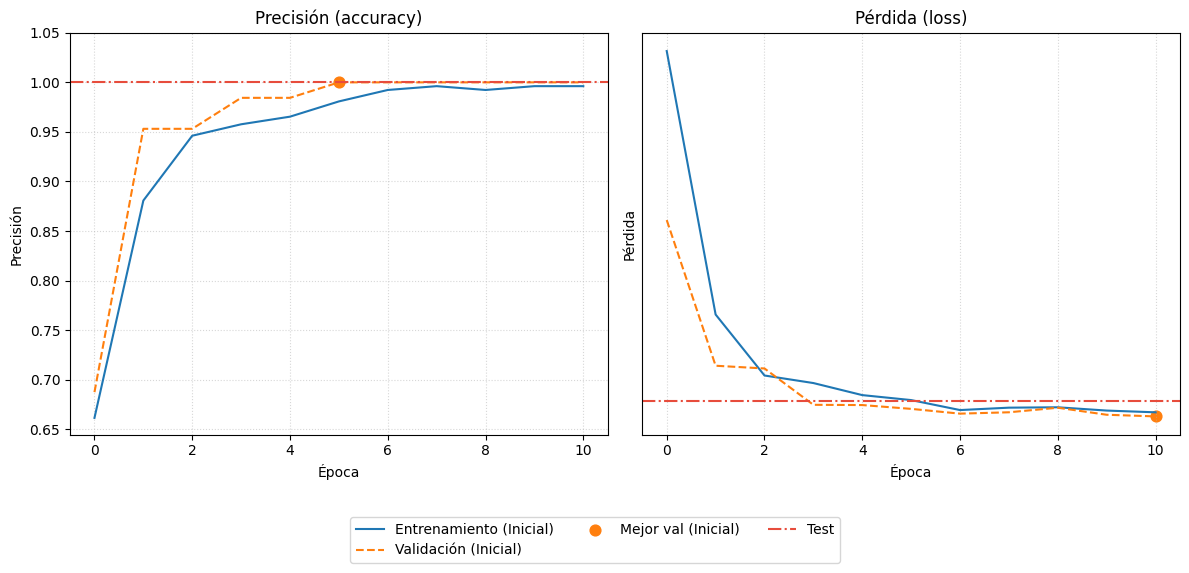

In [7]:

print("Curvas entrenamientos (Sin fine tunning)")
curvasEntrenamiento(history, test_values=test_values)

Ahorra realizamos en fine-tunning (descongelamos las ultimas 100 capas)

In [8]:
base_model_layers = len(base_model.layers)

print(f"El Base model tiene {base_model_layers} capas.")

# Fine-tunning en las ultimas 100 capas
finetunning_layers = 100
fine_tune_at = base_model_layers - finetunning_layers  
print("Capas no entrenables:", fine_tune_at)
print("Capas entrenables:", base_model_layers - fine_tune_at)

# Descongelamos las capas que vamos a entrenar
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompilamos el modelo con un learning rate más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy']
)

fineTunning_epochs = 100 # Ponemos un numero alto para que el entrenamiento se
                         # corte con el TimedStopping
total_epochs = len(history.epoch) + fineTunning_epochs

# Entrenamos el modelo de nuevo
history_fine_tune = model.fit(
    train,
    validation_data=validation,
    epochs=total_epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb, timed_stopping_cb],
    initial_epoch=len(history.epoch)
)

# Insertar el ultimo valor de las curvas de entrenamiento iniciales al inicio
# de las curvas de fine-tunning para conectar las graficas
history_fine_tune.history['accuracy'].insert(0, history.history['accuracy'][-1])
history_fine_tune.history['val_accuracy'].insert(0, history.history['val_accuracy'][-1])
history_fine_tune.history['loss'].insert(0, history.history['loss'][-1])
history_fine_tune.history['val_loss'].insert(0, history.history['val_loss'][-1])


# Evaluamos sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(test)
test_values['finetunning loss'] = test_loss
test_values['finetunning accuracy'] = test_accuracy

El Base model tiene 311 capas.
Capas no entrenables: 211
Capas entrenables: 100
Epoch 12/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.9529 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 2.4410e-05 - learning_rate: 1.0000e-04
Epoch 13/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.9992 - loss: 2.1094e-04 - val_accuracy: 1.0000 - val_loss: 1.2526e-05 - learning_rate: 1.0000e-04
Epoch 14/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.9937 - loss: 6.1805e-04 - val_accuracy: 1.0000 - val_loss: 0.0015 - learning_rate: 1.0000e-04
Epoch 15/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 1.0000 - loss: 1.8385e-04 - val_accuracy: 0.9844 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 16/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 1.0000 - loss: 1.2124e-04 - val_accuracy: 0.9688 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 17/111
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 1.0000 - loss: 7.5310e-06 - val_accuracy: 1.0000 - val_loss: 8.9

Curvas entrenamientos (Luego del fine tunning)


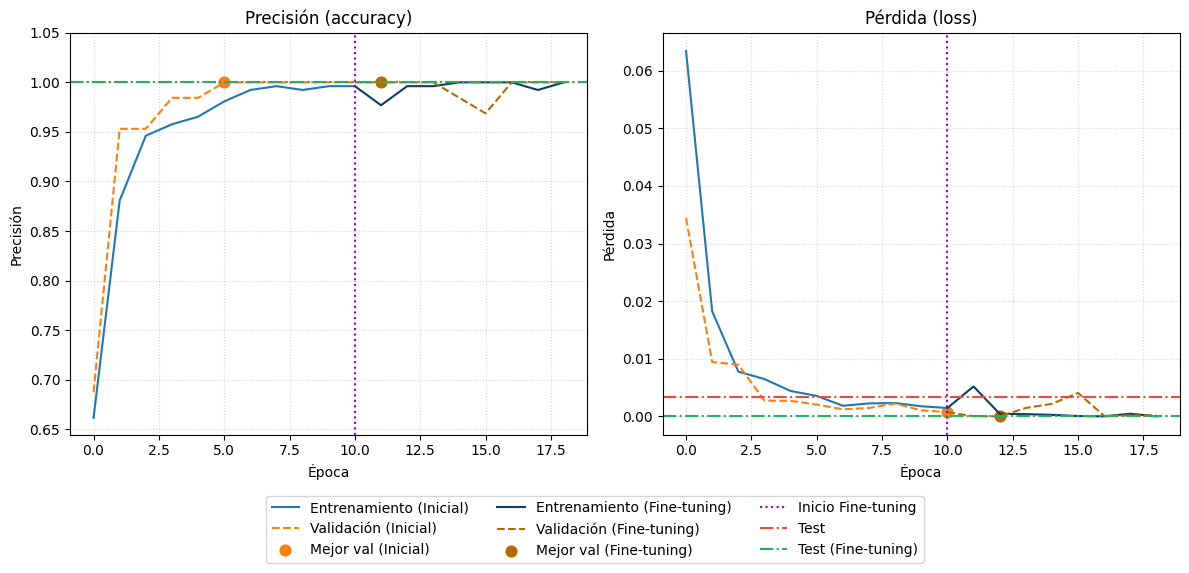

In [19]:
print("Curvas entrenamientos (Luego del fine tunning)")

curvasEntrenamiento(history, history_fine_tune, test_values=test_values)


Veamos como clasifica las imágenes del test

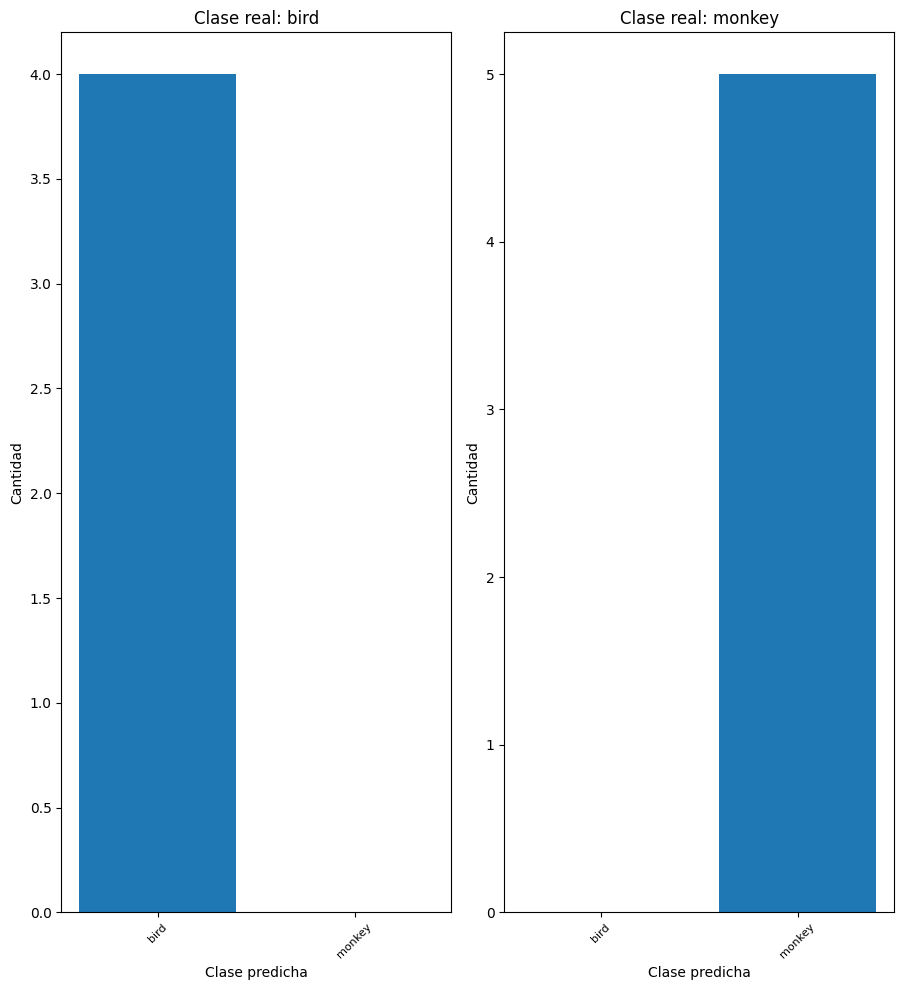

In [10]:
clasificarTest(model, test)

Finalmente guardamos el modelo en un archivo .keras para poder cargarlo luego

In [11]:
model.save('clasificador_naruto.keras')